# Data Understanding: ESC-50 & UrbanSound8K

## Цел на този ноутбук
- **ESC-50**: Разглеждане на 50-те уникални категории и структурата на имената на файловете.
- **UrbanSound8K**: Разглеждане на класовете, метаданните и продължителността на записите.
- **Техническа проверка**: Проверка на Sampling Rate (честота на дискретизация) за консистентност (44.1kHz).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import os
import glob

# Setting style for plots
plt.style.use('ggplot')

## 1. Анализ на ESC-50

In [2]:
# Load ESC-50 metadata
esc50_csv_path = '../data/raw/ESC-50-master/meta/esc50.csv'
df_esc50 = pd.read_csv(esc50_csv_path)

print("ESC-50 Head:")
display(df_esc50.head())

ESC-50 Head:


,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


### Класове в ESC-50
Трябва да има 50 уникални категории.

In [3]:
unique_categories = df_esc50['category'].unique()
n_categories = len(unique_categories)

print(f"Number of unique categories: {n_categories}")
print("Categories:")
print(unique_categories)

# Verify counts
category_counts = df_esc50['category'].value_counts()
print("\nCounts per category (should be 40 per category):")
print(category_counts.describe())

Number of unique categories: 50
Categories:
<StringArray>
[             'dog',   'chirping_birds',   'vacuum_cleaner',
     'thunderstorm',  'door_wood_knock',      'can_opening',
             'crow',         'clapping',        'fireworks',
         'chainsaw',         'airplane',      'mouse_click',
    'pouring_water',            'train',            'sheep',
      'water_drops',     'church_bells',      'clock_alarm',
  'keyboard_typing',             'wind',        'footsteps',
             'frog',              'cow',   'brushing_teeth',
         'car_horn',   'crackling_fire',       'helicopter',
 'drinking_sipping',             'rain',          'insects',
         'laughing',              'hen',           'engine',
        'breathing',      'crying_baby',         'hand_saw',
         'coughing',   'glass_breaking',          'snoring',
     'toilet_flush',              'pig',  'washing_machine',
       'clock_tick',         'sneezing',          'rooster',
        'sea_waves',       

### Структура на имената (ESC-50)
Format: `{fold}-{clip_id}-{take}-{target}.wav`

- **fold**: 1-5 (използва се за cross-validation)
- **clip_id**: уникален идентификатор на изходния запис
- **take**: буква/номер на версията
- **target**: цифров етикет на класа (0-49)

Пример: `1-100032-A-0.wav` -> Fold 1, Target 0 (Dog)

## 2. Анализ на UrbanSound8K

In [4]:
# Load UrbanSound8K metadata
us8k_csv_path = '../data/raw/archive/UrbanSound8K.csv'
df_us8k = pd.read_csv(us8k_csv_path)

print("UrbanSound8K Head:")
display(df_us8k.head())

UrbanSound8K Head:


,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


### Класове в UrbanSound8K

Number of unique classes: 10
Classes:
<StringArray>
[        'dog_bark', 'children_playing',         'car_horn',
  'air_conditioner',     'street_music',         'gun_shot',
            'siren',    'engine_idling',       'jackhammer',
         'drilling']
Length: 10, dtype: str


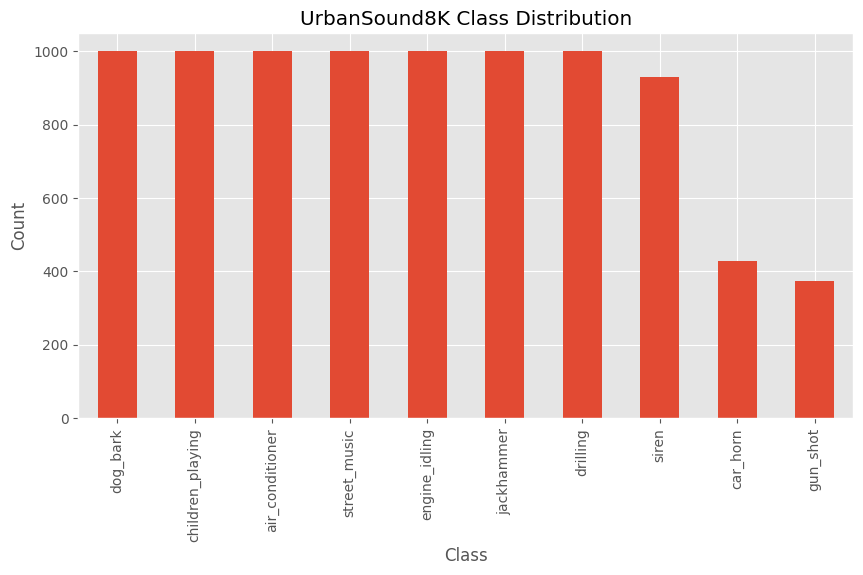

In [5]:
us8k_classes = df_us8k['class'].unique()
print(f"Number of unique classes: {len(us8k_classes)}")
print("Classes:")
print(us8k_classes)

# Plot distribution
plt.figure(figsize=(10, 5))
df_us8k['class'].value_counts().plot(kind='bar')
plt.title('UrbanSound8K Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

### Метаданни: Продължителност (Start/End)
Проверка на продължителността на аудио файловете.

Duration Statistics:
count    8732.000000
mean        3.607904
std         0.973570
min         0.054517
25%         4.000000
50%         4.000000
75%         4.000000
max         4.000000
Name: duration, dtype: float64


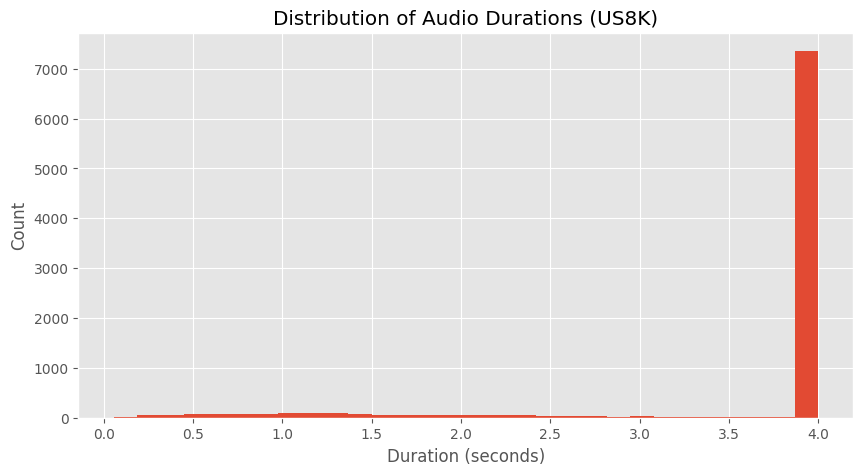

In [6]:
df_us8k['duration'] = df_us8k['end'] - df_us8k['start']
print("Duration Statistics:")
print(df_us8k['duration'].describe())

# Histogram of durations
plt.figure(figsize=(10, 5))
df_us8k['duration'].hist(bins=30)
plt.title('Distribution of Audio Durations (US8K)')
plt.xlabel('Duration (seconds)')
plt.ylabel('Count')
plt.show()

### Анализ на продължителността (Duration)

ESC-50: Всички записи са точно по 5 секунди.

UrbanSound8K: голяма вариация — средно 3.6 сек, но минимумът е едва 0.05 сек

Проблем: Записи под 1-2 секунди може да не съдържат достатъчно информация за разпознаване на контекста.

Препоръка: Филтриране на записи под определена дължина или "подплати" (padding) кратките записи до фиксирана дължина (напр. 4 сек), за да са еднакви входни данни.

## 3. Техническа проверка (Sampling Rate)
Проверка дали всички файлове са с честота 44.1kHz или има вариации. Ще проверим извадка от файлове.

In [7]:
def check_sampling_rate(file_paths, dataset_name, num_samples=5):
    print(f"--- {dataset_name} Sampling Rate Check (Sample of {num_samples}) ---")
    for i, path in enumerate(file_paths[:num_samples]):
        try:
            # sr=None preserves original sampling rate
            # get_samplerate is faster if available, but load is reliable for checking what librosa reads
            sr = librosa.get_samplerate(path)
            print(f"{os.path.basename(path)}: {sr} Hz")
        except Exception as e:
            print(f"Error reading {os.path.basename(path)}: {e}")
            
# ESC-50 Paths
esc50_audio_dir = '../data/raw/ESC-50-master/audio/'
esc50_files = [os.path.join(esc50_audio_dir, f) for f in df_esc50['filename'].sample(5, random_state=42)]

check_sampling_rate(esc50_files, "ESC-50")

print("\n")

# UrbanSound8K Paths
# US8K files are in fold subdirectories
us8k_audio_dir = '../data/raw/archive/'
us8k_sample = df_us8k.sample(5, random_state=42)
us8k_files = []
for idx, row in us8k_sample.iterrows():
    # Construct path: foldX/filename
    path = os.path.join(us8k_audio_dir, f"fold{row.fold}", row.slice_file_name)
    us8k_files.append(path)

check_sampling_rate(us8k_files, "UrbanSound8K")

--- ESC-50 Sampling Rate Check (Sample of 5) ---


/Users/filipapopova/source/repos/Ambient-Sound-Awareness-System-ASAS-/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


5-221950-A-22.wav: 44100 Hz
1-79220-A-17.wav: 44100 Hz
4-165845-A-45.wav: 44100 Hz
3-130330-A-22.wav: 44100 Hz
4-157297-A-21.wav: 44100 Hz


--- UrbanSound8K Sampling Rate Check (Sample of 5) ---
54898-8-0-2.wav: 44100 Hz
172338-9-0-7.wav: 48000 Hz
95562-4-3-0.wav: 44100 Hz
75490-8-0-2.wav: 44100 Hz
128891-3-0-4.wav: 44100 Hz


### Анализ на техническите параметри (Sampling Rate)

ESC-50: Всички файлове са консистентни (44100 Hz). Това е идеално за "домашни" звуци.

UrbanSound8K: Тук се открива вариация (44100 Hz срещу 48000 Hz).

Извод: В скрипта за препроцесиране задължително трябва да се фиксира единен target_sr (напр. 22050 Hz или 16000 Hz). 